In [0]:
pip install nflreadpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 MB 123.0 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import nflreadpy as nfl
pbp_reg = nfl.load_pbp(range(2015, 2026))

In [0]:
pbp.columns

['play_id',
 'game_id',
 'old_game_id',
 'home_team',
 'away_team',
 'season_type',
 'week',
 'posteam',
 'posteam_type',
 'defteam',
 'side_of_field',
 'yardline_100',
 'game_date',
 'quarter_seconds_remaining',
 'half_seconds_remaining',
 'game_seconds_remaining',
 'game_half',
 'quarter_end',
 'drive',
 'sp',
 'qtr',
 'down',
 'goal_to_go',
 'time',
 'yrdln',
 'ydstogo',
 'ydsnet',
 'desc',
 'play_type',
 'yards_gained',
 'shotgun',
 'no_huddle',
 'qb_dropback',
 'qb_kneel',
 'qb_spike',
 'qb_scramble',
 'pass_length',
 'pass_location',
 'air_yards',
 'yards_after_catch',
 'run_location',
 'run_gap',
 'field_goal_result',
 'kick_distance',
 'extra_point_result',
 'two_point_conv_result',
 'home_timeouts_remaining',
 'away_timeouts_remaining',
 'timeout',
 'timeout_team',
 'td_team',
 'td_player_name',
 'td_player_id',
 'posteam_timeouts_remaining',
 'defteam_timeouts_remaining',
 'total_home_score',
 'total_away_score',
 'posteam_score',
 'defteam_score',
 'score_differential',
 'po

In [0]:
import polars as pl
pbp_reg = pbp_reg.filter(pl.col("season_type") == "REG")

In [0]:
# ── Passing
passing = (
    pbp_reg.filter(pl.col("passer_player_id").is_not_null())
    .group_by("passer_player_id", "passer_player_name", "season")
    .agg(
        (pl.col("complete_pass").sum() + pl.col("incomplete_pass").sum()).alias("pass_attempts"),
        pl.col("complete_pass").sum().alias("completions"),
        pl.col("passing_yards").sum().alias("pass_yards"),
        pl.col("pass_touchdown").sum().alias("pass_tds"),
        pl.col("interception").sum().alias("interceptions"),
        pl.col("sack").sum().alias("sacks"),
        pl.col("epa").mean().alias("pass_epa_per_play"),
        pl.col("epa").sum().alias("pass_total_epa"),
    )
    .with_columns([
        (pl.col("completions") / pl.col("pass_attempts")).alias("completion_pct"),
        (pl.col("pass_yards") / pl.col("pass_attempts")).alias("yards_per_attempt"),
        (pl.col("pass_tds") / pl.col("pass_attempts")).alias("pass_td_rate"),
        (pl.col("interceptions") / pl.col("pass_attempts")).alias("int_rate"),
    ])
    .rename({"passer_player_id": "player_id", "passer_player_name": "player_name"})
)

In [0]:
# ── Rushing
rushing = (
    pbp_reg.filter(pl.col("rusher_player_id").is_not_null())
    .group_by("rusher_player_id", "rusher_player_name", "season")
    .agg(
        pl.col("rush_attempt").sum().alias("carries"),
        pl.col("rushing_yards").sum().alias("rush_yards"),
        pl.col("rush_touchdown").sum().alias("rush_tds"),
        (pl.col("rushing_yards") >= 10).sum().alias("explosive_runs"),
        pl.col("fumble").sum().alias("rush_fumbles"),
        pl.col("epa").mean().alias("rush_epa_per_play"),
        pl.col("epa").sum().alias("rush_total_epa"),
    )
    .with_columns([
        (pl.col("rush_yards") / pl.col("carries")).alias("yards_per_carry"),
        (pl.col("rush_tds") / pl.col("carries")).alias("rush_td_rate"),
        (pl.col("explosive_runs") / pl.col("carries")).alias("explosive_run_rate"),
        (pl.col("rush_fumbles") / pl.col("carries")).alias("fumble_rate"),
    ])
    .rename({"rusher_player_id": "player_id", "rusher_player_name": "player_name"})
)

In [0]:
# ── Receiving 
receiving = (
    pbp_reg.filter(pl.col("receiver_player_id").is_not_null())
    .group_by("receiver_player_id", "receiver_player_name", "season")
    .agg(
        pl.col("pass_attempt").sum().alias("targets"),
        pl.col("complete_pass").sum().alias("receptions"),
        pl.col("receiving_yards").sum().alias("rec_yards"),
        pl.col("pass_touchdown").sum().alias("rec_tds"),
        (pl.col("receiving_yards") >= 20).sum().alias("explosive_recs"),
        pl.col("fumble").sum().alias("rec_fumbles"),
        pl.col("air_yards").sum().alias("air_yards"),
        pl.col("yards_after_catch").sum().alias("yac"),
        pl.col("epa").mean().alias("rec_epa_per_play"),
        pl.col("epa").sum().alias("rec_total_epa"),
    )
    .with_columns([
        (pl.col("receptions") / pl.col("targets")).alias("catch_rate"),
        (pl.col("rec_yards") / pl.col("receptions")).alias("yards_per_rec"),
        (pl.col("rec_tds") / pl.col("targets")).alias("rec_td_rate"),
        (pl.col("explosive_recs") / pl.col("receptions")).alias("explosive_rec_rate"),
        (pl.col("air_yards") / pl.col("targets")).alias("air_yards_per_target"),
        (pl.col("yac") / pl.col("receptions")).alias("yac_per_rec"),
    ])
    .rename({"receiver_player_id": "player_id", "receiver_player_name": "player_name"})
)

In [0]:
# Compute games_played once across all play types
games_played = pl.concat([
    pbp_reg.filter(pl.col("passer_player_id").is_not_null())
        .select(pl.col("passer_player_id").alias("player_id"), "season", "game_id"),
    pbp_reg.filter(pl.col("rusher_player_id").is_not_null())
        .select(pl.col("rusher_player_id").alias("player_id"), "season", "game_id"),
    pbp_reg.filter(pl.col("receiver_player_id").is_not_null())
        .select(pl.col("receiver_player_id").alias("player_id"), "season", "game_id"),
]).group_by("player_id", "season").agg(
    pl.col("game_id").n_unique().alias("games_played")
)

In [0]:
# ── Combine into one row per player per season 
# Start from the union of all player/season combos
all_players = pl.concat([
    passing.select("player_id", "player_name", "season"),
    rushing.select("player_id", "player_name", "season"),
    receiving.select("player_id", "player_name", "season"),
]).unique()

player_season = (
    all_players
    .join(passing.drop("player_name"),   on=["player_id", "season"], how="left")
    .join(rushing.drop("player_name"),   on=["player_id", "season"], how="left")
    .join(receiving.drop("player_name"), on=["player_id", "season"], how="left")
    .join(games_played, on=["player_id", "season"], how="left")
    .fill_null(0)
)

In [0]:
contracts = nfl.load_contracts()
contracts.columns

['player',
 'position',
 'team',
 'is_active',
 'year_signed',
 'years',
 'value',
 'apy',
 'guaranteed',
 'apy_cap_pct',
 'inflated_value',
 'inflated_apy',
 'inflated_guaranteed',
 'player_page',
 'otc_id',
 'gsis_id',
 'date_of_birth',
 'height',
 'weight',
 'college',
 'draft_year',
 'draft_round',
 'draft_overall',
 'draft_team',
 'cols']

In [0]:
contracts_clean = contracts.filter(
    pl.col("gsis_id").is_not_null()
).select([
    "gsis_id",
    "player",
    "position",
    "year_signed",
    "years",
    "value",
    "apy",
    "guaranteed",
    "is_active",
    "apy_cap_pct",
    "inflated_value",
    "inflated_apy",
    "inflated_guaranteed",
    "draft_round",
    "draft_overall"
])

In [0]:
contracts_clean = contracts_clean.with_columns([
    (pl.col("year_signed") + pl.col("years") - 1).alias("year_end")
])
contracts_clean.head()

gsis_id,player,position,year_signed,years,value,apy,guaranteed,is_active,apy_cap_pct,inflated_value,inflated_apy,inflated_guaranteed,draft_round,draft_overall,year_end
str,str,str,i32,i32,f64,f64,f64,bool,f64,f64,f64,f64,i32,i32,i32
"""00-0036442""","""Joe Burrow""","""QB""",2023,5,275.0,55.0,146.51,true,0.245,368.460854,73.692171,196.302544,1,1,2027
"""00-0023459""","""Aaron Rodgers""","""QB""",2022,5,150.815,50.271667,101.415,false,0.241,218.181931,72.727311,146.715648,1,24,2026
"""00-0034857""","""Josh Allen""","""QB""",2021,6,258.0,43.0,100.0,false,0.236,425.806027,70.967671,165.041096,1,7,2026
"""00-0029263""","""Russell Wilson""","""QB""",2022,5,245.0,49.0,124.0,false,0.235,354.43804,70.887608,179.389049,3,75,2026
"""00-0033077""","""Dak Prescott""","""QB""",2024,4,240.0,60.0,129.0,true,0.235,283.038371,70.759593,152.133125,4,135,2027


In [0]:
contracts_clean = contracts_clean.sort(["gsis_id", "year_signed"], descending=[False, True])

In [0]:
next_contracts = contracts_clean.select([
    "gsis_id",
    "player",
    "year_signed",
    "apy",
    "years",
    "value",
    "guaranteed",
    "is_active",
    "apy_cap_pct",
    "inflated_value",
    "inflated_apy",
    "inflated_guaranteed",
    "draft_round",
    "draft_overall"
]).rename({
    "year_signed": "next_year_signed",
    "apy": "next_apy",
    "years": "next_years",
    "value": "next_value",
    "guaranteed": "next_guaranteed",
    "apy_cap_pct": "next_apy_cap_pct",
    "inflated_value": "next_inflated_value",
    "inflated_apy": "next_inflated_apy",
    "inflated_guaranteed": "next_inflated_guaranteed",
})
next_contracts.head()

gsis_id,player,next_year_signed,next_apy,next_years,next_value,next_guaranteed,is_active,next_apy_cap_pct,next_inflated_value,next_inflated_apy,next_inflated_guaranteed,draft_round,draft_overall
str,str,i32,f64,i32,f64,f64,bool,f64,f64,f64,f64,i32,i32
"""00-0000108""","""David Akers""",0,1.005,1,1.005,0.1,false,0.0,0.0,0.0,0.0,null,null
"""00-0000585""","""Champ Bailey""",2014,1.875,2,3.75,0.5,false,0.014,8.492481,4.246241,1.132331,1,7
"""00-0000585""","""Champ Bailey""",2011,10.75,4,43.0,10.5,false,0.089,107.593769,26.898442,26.272897,1,7
"""00-0000585""","""Champ Bailey""",2004,6.801,1,6.801,6.801,false,0.084,25.420828,25.420828,25.420828,1,7
"""00-0000585""","""Champ Bailey""",2004,9.004575,7,63.032025,6.0,false,0.112,235.601573,33.657368,22.426845,1,7


In [0]:
next_contracts_clean = (
    next_contracts
    .sort(["gsis_id", "next_year_signed", "next_apy"])
    .group_by(["gsis_id", "next_year_signed"])
    .agg(pl.all().last())
)

In [0]:
# 1. join all contracts to all seasons
joined = player_season.join(
    next_contracts_clean,
    left_on="player_id",
    right_on="gsis_id",
    how="left"
)

# 2. keep only future contracts
future = joined.filter(
    pl.col("next_year_signed").is_null() | 
    (pl.col("next_year_signed") > pl.col("season"))
)

# 3. pick closest future contract
final = (
    future
    .sort(["player_id", "season", "next_year_signed"])
    .group_by(["player_id", "season"])
    .agg(pl.all().first())
)

In [0]:
# season → final contract in that season → next contract in a later season

In [0]:
current_contracts = contracts_clean.rename({
    "year_signed": "curr_year_signed",
    "apy": "curr_apy",
    "years": "curr_years",
    "value": "curr_value",
    "guaranteed": "curr_guaranteed",
    "apy_cap_pct": "curr_apy_cap_pct",
    "inflated_value": "curr_inflated_value",
    "inflated_apy": "curr_inflated_apy",
    "inflated_guaranteed": "curr_inflated_guaranteed",
})

In [0]:
season_features = (
    player_season.join(
        current_contracts,
        left_on="player_id",
        right_on="gsis_id",
        how="left"
    )
    .filter(
        (pl.col("season") >= pl.col("curr_year_signed")) &
        (pl.col("season") <= pl.col("year_end"))
    )
    .sort(["player_id", "season", "curr_year_signed"])
    .unique(subset=["player_id", "season"], keep="last")
)

In [0]:
season_features

player_id,player_name,season,pass_attempts,completions,pass_yards,pass_tds,interceptions,sacks,pass_epa_per_play,pass_total_epa,completion_pct,yards_per_attempt,pass_td_rate,int_rate,carries,rush_yards,rush_tds,explosive_runs,rush_fumbles,rush_epa_per_play,rush_total_epa,yards_per_carry,rush_td_rate,explosive_run_rate,fumble_rate,targets,receptions,rec_yards,rec_tds,explosive_recs,rec_fumbles,air_yards,yac,rec_epa_per_play,rec_total_epa,catch_rate,yards_per_rec,rec_td_rate,explosive_rec_rate,air_yards_per_target,yac_per_rec,games_played,player,position,curr_year_signed,curr_years,curr_value,curr_apy,curr_guaranteed,is_active,curr_apy_cap_pct,curr_inflated_value,curr_inflated_apy,curr_inflated_guaranteed,draft_round,draft_overall,year_end
str,str,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,str,i32,i32,f64,f64,f64,bool,f64,f64,f64,f64,i32,i32,i32
"""00-0027003""","""D.Brown""",2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,59.0,229.0,1.0,6,0.0,-0.132814,-7.836046,3.881356,0.016949,0.101695,0.0,13.0,8.0,88.0,0.0,2,1.0,-36.0,110.0,0.199691,2.595978,0.615385,11.0,0.0,0.25,-2.769231,13.75,6,"""Donald Brown""","""RB""",2015,2,6.5,3.25,0.0,false,0.023,13.664154,6.832077,0.0,1,27,2016
"""00-0035287""","""K.Johnson""",2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0,0.0,-0.647963,-0.647963,3.0,0.0,0.0,0.0,43.0,21.0,187.0,1.0,1,1.0,394.0,43.0,-0.149294,-6.419639,0.488372,8.904762,0.023256,0.047619,9.162791,2.047619,10,"""KeeSean Johnson""","""WR""",2019,4,2.729312,0.682328,0.209312,false,0.004,4.368059,1.092015,0.334988,6,174,2022
"""00-0030506""","""T.Kelce""",2023,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,121.0,93.0,984.0,5.0,12,2.0,807.0,470.0,0.396818,48.015015,0.768595,10.580645,0.041322,0.129032,6.669421,5.053763,15,"""Travis Kelce""","""TE""",2020,4,57.25,14.3125,21.0,false,0.072,87.001514,21.750378,31.913219,3,63,2023
"""00-0037253""","""Ma.Jones""",2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,4.0,78.0,1.0,1,0.0,-17.0,95.0,1.594512,6.378046,1.0,19.5,0.25,0.25,-4.25,23.75,3,"""Marcus Jones""","""CB""",2022,4,5.176952,1.294238,0.945056,false,0.006,7.489423,1.872356,1.367199,3,85,2025
"""00-0033006""","""J.Mickens""",2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,7.0,58.0,0.0,0,0.0,73.0,31.0,0.459322,4.593218,0.7,8.285714,0.0,0.0,7.3,4.428571,2,"""Jaydon Mickens""","""WR""",2020,2,1.67,0.835,0.0,false,0.004,2.537861,1.26893,0.0,null,null,2021
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""00-0035645""","""G.Olszewski""",2021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0,0.0,0,0.0,0.76596,0.76596,9.0,0.0,0.0,0.0,3.0,2.0,31.0,0.0,1,0.0,29.0,14.0,0.559231,1.677693,0.666667,15.5,0.0,0.5,9.666667,7.0,4,"""Gunner Olszewski""","""WR""",2019,3,1.7575,0.585833,0.0025,false,0.003,2.812747,0.937582,0.004001,null,null,2021
"""00-0030569""","""S.Renfree""",2015,6.0,3.0,11.0,0.0,1.0,2.0,-0.824322,-7.4189,0.5,1.833333,0.0,0.166667,2.0,-4.0,0.0,0,0.0,-0.967829,-1.935659,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,"""Sean Renfree""","""QB""",2013,4,2.205896,0.551474,0.045896,false,0.004,5.401755,1.350439,0.112389,7,249,2016
"""00-0032160""","""T.Williams""",2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,2.0,90.0,1.0,1,0.0,161.0,51.0,-0.102325,-0.613951,0.333333,45.0,0.166667,0.5,26.833333,25.5,2,"""Tyrell Williams""","""WR""",2015,3,1.575,0.525,0.0,false,0.004,3.31093,1.103643,0.0,null,null,2017


In [0]:
dataset = season_features.join(
    final,
    on=["player_id", "season"],
    how="left"
)

In [0]:
dataset = dataset.select(
    [col for col in dataset.columns if not col.endswith("_right")]
)
dataset

player_id,player_name,season,pass_attempts,completions,pass_yards,pass_tds,interceptions,sacks,pass_epa_per_play,pass_total_epa,completion_pct,yards_per_attempt,pass_td_rate,int_rate,carries,rush_yards,rush_tds,explosive_runs,rush_fumbles,rush_epa_per_play,rush_total_epa,yards_per_carry,rush_td_rate,explosive_run_rate,fumble_rate,targets,receptions,rec_yards,rec_tds,explosive_recs,rec_fumbles,air_yards,yac,rec_epa_per_play,rec_total_epa,catch_rate,yards_per_rec,rec_td_rate,explosive_rec_rate,air_yards_per_target,yac_per_rec,games_played,player,position,curr_year_signed,curr_years,curr_value,curr_apy,curr_guaranteed,is_active,curr_apy_cap_pct,curr_inflated_value,curr_inflated_apy,curr_inflated_guaranteed,draft_round,draft_overall,year_end,next_year_signed,next_apy,next_years,next_value,next_guaranteed,next_apy_cap_pct,next_inflated_value,next_inflated_apy,next_inflated_guaranteed
str,str,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,str,i32,i32,f64,f64,f64,bool,f64,f64,f64,f64,i32,i32,i32,i32,f64,i32,f64,f64,f64,f64,f64,f64
"""00-0026189""","""D.Jackson""",2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.0,9.0,153.0,0.0,2,1.0,302.0,23.0,0.096107,1.633827,0.529412,17.0,0.0,0.222222,17.764706,2.555556,7,"""DeSean Jackson""","""WR""",2022,1,0.365766,0.365766,0.0,false,0.002,0.529149,0.529149,0.0,2,49,2022,null,null,null,null,null,null,null,null,null
"""00-0031357""","""C.Goodwin""",2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0.0,9.0,0.0,-3.321605,-3.321605,0.0,NaN,0.0,NaN,9.0,NaN,1,"""C.J. Goodwin""","""CB""",2020,1,1.0475,1.0475,0.3375,false,0.005,1.591862,1.591862,0.512891,null,null,2020,2021,1.75,2,3.5,2.0,0.01,5.776438,2.888219,3.300822
"""00-0033217""","""M.Alie-Cox""",2025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,13.0,117.0,1.0,1,0.0,93.0,77.0,-0.042963,-0.85927,0.65,9.0,0.05,0.076923,4.65,5.923077,11,"""Mo Alie-Cox""","""TE""",2025,1,2.2,2.2,1.1675,false,0.008,2.373352,2.373352,1.259495,null,null,2025,2026,2.6875,1,2.6875,2.1875,0.009,2.6875,2.6875,2.1875
"""00-0032765""","""M.Thomas""",2016,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,121.0,92.0,1137.0,9.0,18,2.0,961.0,483.0,0.225783,27.319729,0.760331,12.358696,0.07438,0.195652,7.942149,5.25,15,"""Michael Thomas""","""WR""",2016,4,5.118974,1.279744,3.055569,false,0.008,9.930025,2.482507,5.927335,2,47,2019,2019,19.25,5,96.25,35.648043,0.102,154.040914,30.808183,57.052022
"""00-0036096""","""J.Taylor""",2024,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,44.0,0.0,0,0.0,-0.002501,-0.025006,4.4,0.0,0.0,0.0,3.0,2.0,0.0,0.0,0,0.0,-6.0,1.0,-0.831121,-2.493362,0.666667,0.0,0.0,0.0,-2.0,0.5,3,"""J.J. Taylor""","""RB""",2024,1,0.225,0.225,0.0,false,0.001,0.265348,0.265348,0.0,null,null,2024,2025,1.1,1,1.1,0.0,0.004,1.186676,1.186676,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""00-0036768""","""J.Hardy""",2021,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,29.0,1.0,1,0.0,0.658764,2.635056,7.25,0.25,0.25,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,"""JaQuan Hardy""","""RB""",2021,3,2.43,0.81,0.055,false,0.004,4.010499,1.336833,0.090773,null,null,2023,2022,0.8825,2,1.765,0.0,0.004,2.553401,1.2767,0.0
"""00-0033382""","""A.Carr""",2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,9.0,0.0,0,0.0,41.0,4.0,-0.307052,-1.228209,0.25,9.0,0.0,0.0,10.25,4.0,2,"""Austin Carr""","""WR""",2017,3,1.6725,0.5575,0.03,false,0.003,3.016509,1.005503,0.054108,null,null,2019,2020,0.825,1,0.825,0.0,0.004,1.253734,1.253734,0.0
"""00-0030279""","""K.Allen""",2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [0]:
players = nfl.load_players()

players_pl = (
    players.select(['gsis_id', 'birth_date'])
    .unique()
    .rename({'gsis_id': 'player_id'})
    .with_columns(pl.col('birth_date').cast(pl.Date))
)

dataset = (
    dataset.join(players_pl, on='player_id', how='left')
    .with_columns(
        (
            (
                pl.date(pl.col('season') + 1, 9, 1) - pl.col('birth_date')
            ).dt.total_days() / 365.25
        ).round(1).alias('next_season_age')
    )
    .drop('birth_date')
)

In [0]:
# 1. Sort and rank to assign the "lag_number"
dataset = dataset.sort(["player_id", "season"], descending=[False, True])

dataset = dataset.with_columns(
    pl.col("season")
    .rank("ordinal", descending=True)
    .over(["player_id", "next_year_signed"])
    .alias("lag_number")
)

# 2. Filter to your max lookback window (e.g., 4 years)
max_lags = 4
dataset = dataset.filter(pl.col("lag_number") <= max_lags)

# 3. Define ALL on-field season stats for the pivot
stat_cols = [
    "pass_attempts", "completions", "pass_yards", "pass_tds", "interceptions", "sacks",
    "pass_epa_per_play", "pass_total_epa", "completion_pct", "yards_per_attempt", 
    "pass_td_rate", "int_rate", "carries", "rush_yards", "rush_tds", "explosive_runs", 
    "rush_fumbles", "rush_epa_per_play", "rush_total_epa", "yards_per_carry", 
    "rush_td_rate", "explosive_run_rate", "fumble_rate", "targets", "receptions", 
    "rec_yards", "rec_tds", "explosive_recs", "rec_fumbles", "air_yards", "yac", 
    "rec_epa_per_play", "rec_total_epa", "catch_rate", "yards_per_rec", "rec_td_rate", 
    "explosive_rec_rate", "air_yards_per_target", "yac_per_rec", "games_played"
]

# 4. Define ALL static traits, current contract context, and prediction targets
index_cols = [
    "player_id", "player_name", "position", "draft_round", "draft_overall", "year_end",
    "curr_year_signed", "curr_years", "curr_value", "curr_apy", "curr_guaranteed", 
    "is_active", "curr_apy_cap_pct", "curr_inflated_value", "curr_inflated_apy", "curr_inflated_guaranteed",
    "next_year_signed", "next_apy", "next_years", "next_value", "next_guaranteed", 
    "next_apy_cap_pct", "next_inflated_value", "next_inflated_apy", "next_inflated_guaranteed", 
    "next_season_age", "player"
]


# 5. CREATE THE MASTER CONTRACT TABLE (Only Walk Years)
contract_events = dataset.filter(pl.col("lag_number") == 1).select(index_cols)

# 6. FLATTEN THE STATS (Using ONLY the strict IDs as the index)
flattened_stats = dataset.pivot(
    values=stat_cols,
    index=["player_id", "next_year_signed"],
    on="lag_number",
    aggregate_function="first"
)

# 7. JOIN THEM TOGETHER
final_dataset = contract_events.join(
    flattened_stats,
    on=["player_id", "next_year_signed"],
    how="left"
)

In [0]:
final_dataset.filter(pl.col("player") == "Christian McCaffrey") \
                 .sort("next_year_signed")

player_id,player_name,position,draft_round,draft_overall,year_end,curr_year_signed,curr_years,curr_value,curr_apy,curr_guaranteed,is_active,curr_apy_cap_pct,curr_inflated_value,curr_inflated_apy,curr_inflated_guaranteed,next_year_signed,next_apy,next_years,next_value,next_guaranteed,next_apy_cap_pct,next_inflated_value,next_inflated_apy,next_inflated_guaranteed,next_season_age,player,pass_attempts_1,pass_attempts_2,pass_attempts_3,pass_attempts_4,completions_1,completions_2,completions_3,completions_4,pass_yards_1,pass_yards_2,…,yac_4,rec_epa_per_play_1,rec_epa_per_play_2,rec_epa_per_play_3,rec_epa_per_play_4,rec_total_epa_1,rec_total_epa_2,rec_total_epa_3,rec_total_epa_4,catch_rate_1,catch_rate_2,catch_rate_3,catch_rate_4,yards_per_rec_1,yards_per_rec_2,yards_per_rec_3,yards_per_rec_4,rec_td_rate_1,rec_td_rate_2,rec_td_rate_3,rec_td_rate_4,explosive_rec_rate_1,explosive_rec_rate_2,explosive_rec_rate_3,explosive_rec_rate_4,air_yards_per_target_1,air_yards_per_target_2,air_yards_per_target_3,air_yards_per_target_4,yac_per_rec_1,yac_per_rec_2,yac_per_rec_3,yac_per_rec_4,games_played_1,games_played_2,games_played_3,games_played_4
str,str,str,i32,i32,i32,i32,i32,f64,f64,f64,bool,f64,f64,f64,f64,i32,f64,i32,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,u32,u32,u32
"""00-0033280""","""C.McCaffrey""","""RB""",1,8,2025,2024,2,38.0,19.0,24.0,true,0.074,44.814409,22.407204,28.303837,null,null,null,null,null,null,null,null,null,30.2,"""Christian McCaffrey""",null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""00-0033280""","""C.McCaffrey""","""RB""",1,8,2020,2017,4,17.241304,4.310326,17.241304,false,0.026,31.096292,7.774073,31.096292,2020,16.015853,4,64.063412,30.0625,0.081,97.3557,24.338925,45.685293,24.2,"""Christian McCaffrey""",2.0,1.0,0.0,null,0.0,1.0,0.0,null,0.0,50.0,…,null,0.355514,0.2668,0.100921,null,50.483007,33.349967,11.404118,null,0.816901,0.856,0.707965,null,8.663793,8.102804,8.1375,null,0.028169,0.048,0.044248,null,0.060345,0.102804,0.0875,null,0.78169,0.672,2.168142,null,8.508621,8.028037,7.4125,null,16,16,16,null
"""00-0033280""","""C.McCaffrey""","""RB""",1,8,2023,2020,4,64.063412,16.015853,30.0625,false,0.081,97.3557,24.338925,45.685293,2024,19.0,2,38.0,24.0,0.074,44.814409,22.407204,28.303837,28.2,"""Christian McCaffrey""",0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,34.0,…,120.0,0.077769,0.190477,0.514229,0.469038,6.454787,20.57156,21.0834,8.911715,0.807229,0.787037,0.902439,0.894737,8.41791,8.717647,9.27027,8.588235,0.084337,0.046296,0.02439,0.052632,0.059701,0.094118,0.108108,0.058824,1.843373,1.231481,2.219512,1.421053,6.880597,8.176471,6.972973,7.058824,16,17,7,3


In [0]:
final_dataset

player_id,player_name,position,draft_round,draft_overall,year_end,curr_year_signed,curr_years,curr_value,curr_apy,curr_guaranteed,is_active,curr_apy_cap_pct,curr_inflated_value,curr_inflated_apy,curr_inflated_guaranteed,next_year_signed,next_apy,next_years,next_value,next_guaranteed,next_apy_cap_pct,next_inflated_value,next_inflated_apy,next_inflated_guaranteed,next_season_age,player,pass_attempts_1,pass_attempts_2,pass_attempts_3,pass_attempts_4,completions_1,completions_2,completions_3,completions_4,pass_yards_1,pass_yards_2,…,yac_4,rec_epa_per_play_1,rec_epa_per_play_2,rec_epa_per_play_3,rec_epa_per_play_4,rec_total_epa_1,rec_total_epa_2,rec_total_epa_3,rec_total_epa_4,catch_rate_1,catch_rate_2,catch_rate_3,catch_rate_4,yards_per_rec_1,yards_per_rec_2,yards_per_rec_3,yards_per_rec_4,rec_td_rate_1,rec_td_rate_2,rec_td_rate_3,rec_td_rate_4,explosive_rec_rate_1,explosive_rec_rate_2,explosive_rec_rate_3,explosive_rec_rate_4,air_yards_per_target_1,air_yards_per_target_2,air_yards_per_target_3,air_yards_per_target_4,yac_per_rec_1,yac_per_rec_2,yac_per_rec_3,yac_per_rec_4,games_played_1,games_played_2,games_played_3,games_played_4
str,str,str,i32,i32,i32,i32,i32,f64,f64,f64,bool,f64,f64,f64,f64,i32,f64,i32,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,u32,u32,u32
"""00-0007091""","""M.Hasselbeck""","""QB""",6,187,2015,2015,1,3.0,3.0,1.0,false,0.021,6.306533,6.306533,2.102178,null,null,null,null,null,null,null,null,null,40.9,"""Matt Hasselbeck""",null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""00-0010346""","""P.Manning""","""QB""",1,1,2016,2015,2,34.0,17.0,15.0,false,0.119,71.474037,35.737018,31.532663,null,null,null,null,null,null,null,null,null,40.4,"""Peyton Manning""",null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""00-0018227""","""C.Woodson""","""S""",1,4,2015,2015,1,3.2,3.2,1.4,false,0.022,6.726968,6.726968,2.943049,null,null,null,null,null,null,null,null,null,39.9,"""Charles Woodson""",null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""00-0019596""","""T.Brady""","""QB""",6,199,2021,2021,1,25.0,25.0,25.0,false,0.137,41.260274,41.260274,41.260274,null,null,null,null,null,null,null,null,null,45.1,"""Tom Brady""",null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""00-0019596""","""T.Brady""","""QB""",6,199,2021,2020,2,50.0,25.0,50.0,false,0.126,75.983855,37.991927,75.983855,2021,25.0,1,25.0,25.0,0.137,41.260274,41.260274,41.260274,44.1,"""Tom Brady""",598.0,null,null,null,401.0,null,null,null,4633.0,null,…,null,0.0,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,null,null,null,0.0,null,null,null,16,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""00-0040737""","""T.Ferguson""","""TE""",2,46,2028,2025,4,9.713466,2.428367,8.046753,true,0.009,10.478854,2.619714,8.680809,null,null,null,null,null,null,null,null,null,23.5,"""Terrance Ferguson""",null,null,null,null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,nul

In [0]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 MB 145.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 82.5 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
# Clean and define the master df
df_clean = final_dataset.drop_nulls(subset=["next_year_signed"])

# 1. Define the Salary Cap Mapping (Official NFL Figures)
cap_mapping = {
    2015: 143.28, 2016: 155.27, 2017: 167.0, 2018: 177.2, 
    2019: 188.2, 2020: 198.2, 2021: 182.5, 2022: 208.2, 
    2023: 224.8, 2024: 255.4, 2025: 279.2, 2026: 301.2
}

# 2. Add the column to your Polars DataFrame
df_clean = df_clean.with_columns(
    pl.col("next_year_signed").replace(cap_mapping).alias("yearly_cap")
)

# Split by time (Train on history, Test on 2023+)
train_pl = df_clean.filter(pl.col('next_year_signed') < 2023)
test_pl = df_clean.filter(pl.col('next_year_signed') >= 2023)

In [0]:
import polars as pl
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.compose import TransformedTargetRegressor
# Define exactly which base_stats go with which position
# RBs get their rushing stats AND the receiving stats you wanted
pos_map = {
    'QB': ["pass_attempts", "completions", "pass_yards", "pass_tds", "interceptions", "sacks", 
           "pass_epa_per_play", "completion_pct", "yards_per_attempt", "pass_td_rate", "int_rate", 
           "carries", "rush_yards", "rush_tds", "rush_epa_per_play"],
    'WR': ["targets", "receptions", "rec_yards", "rec_tds", "explosive_recs", "rec_fumbles", 
           "rec_epa_per_play", "yards_per_rec", "rec_td_rate", "explosive_rec_rate", 
           "air_yards_per_target", "yac_per_rec"],
    'RB': ["carries", "rush_yards", "rush_tds", "explosive_runs", "rush_fumbles", "rush_epa_per_play", 
           "yards_per_carry", "rush_td_rate", "explosive_run_rate", "fumble_rate",
           "targets", "receptions", "rec_yards", "rec_tds", "yac_per_rec"], # RB Receiving stats added
    'TE': ["targets", "receptions", "rec_yards", "rec_tds", "explosive_recs", "rec_fumbles", 
           "rec_epa_per_play", "yards_per_rec", "rec_td_rate", "explosive_rec_rate", 
           "air_yards_per_target", "yac_per_rec"]
}

static_features = [
    "position", "draft_overall", "curr_years", 
    "curr_inflated_apy", "curr_inflated_guaranteed", "next_season_age", "yearly_cap"
]

# Build grid
param_grid = {
    'regressor__max_depth': [3, 4, 5, 6, 8],           
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2], 
    'regressor__n_estimators': [100, 250, 500, 750],    
    'regressor__subsample': [0.8, 0.9, 1.0],            
    'regressor__colsample_bytree': [0.7, 0.8, 0.9, 1.0] 
}

final_models = {
    'next_inflated_apy': {},
    'next_years': {},
    'next_guaranteed': {}
}

# The loop now builds the feature list correctly
for pos in ['QB', 'WR', 'RB', 'TE']:
    # 1. Get the 1-4 lags for only the allowed stats for this position
    current_lagged = [f"{stat}_{lag}" for stat in pos_map[pos] for lag in range(1, 5)]
    
    # 2. Combine with your static features (excluding 'position' from X)
    current_features = [f for f in static_features if f != 'position'] + current_lagged + ["games_played_1", "games_played_2", "games_played_3", "games_played_4"]

    # Now filter your Polars DF
    pos_df = train_pl.filter(pl.col('position') == pos)
    X = pos_df.select(current_features).to_pandas()

    pos_groups = pos_df['player_id'].to_pandas()
  
    for target in ['next_inflated_apy', 'next_years', 'next_guaranteed']:
        y = pos_df[target].to_pandas()
        
        # Determine if we use Log Transformation (Money vs Years)
        if target in ['next_inflated_apy', 'next_guaranteed']:
            wrapper = TransformedTargetRegressor(
                regressor=XGBRegressor( random_state=42),
                func=np.log1p, 
                inverse_func=np.expm1
            )
        else:
            # next_years stays linear
            wrapper = TransformedTargetRegressor(
                regressor=XGBRegressor(random_state=42),
                func=None, inverse_func=None
            )

        # 3-Fold CV for the smaller positional groups
        # Use GroupKFold with 3 or 5 splits depending on how much data each pos has
        # Note: If a position has very few players, n_splits=5 might be too high.
        n_splits = 5 if len(pos_groups.unique()) >= 5 else 3
        gkf = GroupKFold(n_splits=n_splits)

        grid_search = RandomizedSearchCV(
    estimator=wrapper,
    param_distributions=param_grid, # Note the name change to 'param_distributions'
    n_iter=25,                     # This tells the model to try 25 random combos
    cv=gkf, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42                # Keeps your results consistent
)
        
        # Pass the groups to the fit method!
        grid_search.fit(X, y, groups=pos_groups)

        final_models[target][pos] = grid_search.best_estimator_
        print(f"Finished {pos} {target} | Best CV RMSE: {-grid_search.best_score_:.4f}")

Finished QB next_inflated_apy | Best CV RMSE: 9.4968
Finished QB next_years | Best CV RMSE: 0.9546
Finished QB next_guaranteed | Best CV RMSE: 16.4139
Finished WR next_inflated_apy | Best CV RMSE: 3.9388
Finished WR next_years | Best CV RMSE: 0.7414
Finished WR next_guaranteed | Best CV RMSE: 4.6182
Finished RB next_inflated_apy | Best CV RMSE: 2.4361
Finished RB next_years | Best CV RMSE: 0.7321
Finished RB next_guaranteed | Best CV RMSE: 2.9485
Finished TE next_inflated_apy | Best CV RMSE: 2.8436
Finished TE next_years | Best CV RMSE: 0.8516
Finished TE next_guaranteed | Best CV RMSE: 3.1653


In [0]:
hp_list = []

for target in ['next_inflated_apy', 'next_years', 'next_guaranteed']:
    for pos in ['QB', 'WR', 'RB', 'TE']:
        # Dig into the wrapper to get the fitted XGBoost regressor
        fitted_model = final_models[target][pos].regressor_
        
        # Pull the best params from the RandomizedSearchCV results (if stored) 
        # or directly from the fitted estimator
        params = fitted_model.get_params()
        
        hp_list.append({
            'Predicting': target,
            'Position': pos,
            'max_depth': params.get('max_depth'),
            'learning_rate': params.get('learning_rate'),
            'n_estimators': params.get('n_estimators'),
            'subsample': params.get('subsample'),
            'colsample_bytree': params.get('colsample_bytree')
        })

hp_df = pd.DataFrame(hp_list)
# Display with a clean index
display(hp_df.sort_values(['Position', 'Predicting']))

Predicting,Position,max_depth,learning_rate,n_estimators,subsample,colsample_bytree
next_guaranteed,QB,5,0.2,750,1.0,0.7
next_inflated_apy,QB,4,0.2,750,1.0,1.0
next_years,QB,4,0.01,750,0.8,0.8
next_guaranteed,RB,3,0.05,500,0.9,0.7
next_inflated_apy,RB,3,0.1,100,0.8,0.7
next_years,RB,5,0.05,100,1.0,0.7
next_guaranteed,TE,4,0.2,100,0.9,1.0
next_inflated_apy,TE,5,0.01,500,0.8,0.7
next_years,TE,4,0.01,250,0.9,1.0
next_guaranteed,WR,3,0.05,500,0.9,0.7


In [0]:
# Dictionary to store a separate table for each position
pos_results = {}

for pos in ['QB', 'WR', 'RB', 'TE']:
    # Filter test set
    pos_test_pl = test_pl.filter(pl.col('position') == pos)
    
    if pos_test_pl.height == 0:
        continue
        
    # Reconstruct the feature list for this position
    current_lagged = [f"{stat}_{lag}" for stat in pos_map[pos] for lag in range(1, 5)]
    current_features = [f for f in static_features if f != 'position'] + current_lagged + ["games_played_1", "games_played_2", "games_played_3", "games_played_4"]
    
    X_test_pos = pos_test_pl.select(current_features).to_pandas()
    
    # Create the comparison table
    # We round for readability
    df_res = pos_test_pl.select(['player', 'next_year_signed']).to_pandas()
    
    # APY Comparison
    df_res['Actual_APY'] = pos_test_pl['next_inflated_apy'].to_pandas().round(2)
    df_res['Pred_APY'] = final_models['next_inflated_apy'][pos].predict(X_test_pos).round(2)
    
    # Years Comparison
    df_res['Actual_Years'] = pos_test_pl['next_years'].to_pandas().round(1)
    df_res['Pred_Years'] = final_models['next_years'][pos].predict(X_test_pos).round(1)
    
    # Guaranteed Comparison
    df_res['Actual_Guar'] = pos_test_pl['next_guaranteed'].to_pandas().round(2)
    df_res['Pred_Guar'] = final_models['next_guaranteed'][pos].predict(X_test_pos).round(2)
    
    # Add an Error column for the primary metric (APY)
    df_res['APY_Error'] = (df_res['Pred_APY'] - df_res['Actual_APY']).round(2)
    
    # Sort by the biggest actual contracts and store
    pos_results[pos] = df_res.sort_values('Actual_APY', ascending=False)

In [0]:
# --- HOW TO VIEW THE DATA ---
print("Results for QBs:")
display(pos_results['QB'].head(10))

Results for QBs:


player,next_year_signed,Actual_APY,Pred_APY,Actual_Years,Pred_Years,Actual_Guar,Pred_Guar,APY_Error
Joe Burrow,2023,73.69,49.47,5,4.5,146.51,56.79,-24.22
Dak Prescott,2024,70.76,47.65,4,3.0,129.0,51.03,-23.11
Justin Herbert,2023,70.34,37.06,5,3.9,133.74,33.76,-33.28
Lamar Jackson,2023,69.67,7.47,5,3.2,135.0,3.11,-62.2
Jalen Hurts,2023,68.33,57.22,5,3.9,110.0,45.88,-11.11
Trevor Lawrence,2024,64.86,45.38,5,3.7,142.0,84.44,-19.48
Jordan Love,2024,64.86,37.95,4,2.8,100.8,60.1,-26.91
Tua Tagovailoa,2024,62.62,27.66,4,2.6,93.17,39.58,-34.96
Jared Goff,2024,62.5,56.59,4,2.2,113.61,55.77,-5.91
Josh Allen,2025,59.33,75.96,6,4.4,147.0,62.92,16.63


In [0]:

print("\nResults for RBs:")
display(pos_results['RB'].head(10))


Results for RBs:


player,next_year_signed,Actual_APY,Pred_APY,Actual_Years,Pred_Years,Actual_Guar,Pred_Guar,APY_Error
Christian McCaffrey,2024,22.41,16.1,2,3.8,24.0,14.8,-6.31
Saquon Barkley,2025,22.22,11.46,2,3.8,36.0,5.62,-10.76
Jonathan Taylor,2023,18.76,6.93,3,2.3,19.35,4.59,-11.83
Derrick Henry,2025,16.18,9.46,2,3.7,25.0,4.1,-6.72
Josh Jacobs,2023,15.8,15.29,1,4.1,10.09,7.76,-0.51
Aaron Jones,2023,15.41,8.11,2,3.8,8.52,4.12,-7.3
Saquon Barkley,2024,14.84,5.72,3,1.7,26.0,3.46,-9.12
Alvin Kamara,2024,14.45,7.18,2,2.4,19.23,4.27,-7.27
Kenneth Walker III,2026,14.35,5.73,3,2.3,28.7,4.78,-8.62
Breece Hall,2026,14.29,11.63,1,3.8,0.0,7.5,-2.66


In [0]:

print("\nResults for WRs:")
display(pos_results['WR'].head(10))


Results for WRs:


player,next_year_signed,Actual_APY,Pred_APY,Actual_Years,Pred_Years,Actual_Guar,Pred_Guar,APY_Error
Ja'Marr Chase,2025,43.42,40.99,4,3.0,73.9,53.73,-2.43
Jaxon Smith-Njigba,2026,42.15,24.7,4,3.3,69.13,22.8,-17.45
Justin Jefferson,2024,41.28,35.48,4,4.0,88.74,44.73,-5.8
CeeDee Lamb,2024,40.1,37.64,4,4.0,67.0,30.89,-2.46
A.J. Brown,2024,37.74,34.7,3,3.3,51.0,31.22,-3.04
D.K. Metcalf,2025,35.6,18.22,4,2.5,60.0,22.7,-17.38
Brandon Aiyuk,2024,35.38,35.5,4,3.1,45.0,28.57,0.12
Tyreek Hill,2024,35.38,23.91,3,3.3,54.0,18.43,-11.47
Amon-Ra St. Brown,2024,35.38,36.92,4,3.6,34.67,29.29,1.54
Garrett Wilson,2025,35.06,35.7,4,3.3,38.32,26.65,0.64


In [0]:

print("\nResults for TEs:")
display(pos_results['TE'].head(10))


Results for TEs:


player,next_year_signed,Actual_APY,Pred_APY,Actual_Years,Pred_Years,Actual_Guar,Pred_Guar,APY_Error
T.J. Hockenson,2023,22.11,13.6,4,2.3,29.29,8.81,-8.51
George Kittle,2025,20.61,12.6,4,2.5,35.0,7.01,-8.01
Trey McBride,2025,20.5,15.65,4,2.9,32.5,17.13,-4.85
Travis Kelce,2024,20.2,13.44,2,2.5,17.0,10.6,-6.76
Evan Engram,2023,18.42,11.94,3,2.5,24.0,10.54,-6.48
Cole Kmet,2023,16.75,13.66,4,3.3,22.89,19.36,-3.09
Kyle Pitts,2026,15.04,10.05,1,2.8,0.0,5.53,-4.99
Pat Freiermuth,2024,14.27,10.72,4,2.4,11.6,7.76,-3.55
Dalton Schultz,2024,14.15,13.41,3,2.2,23.5,8.77,-0.74
Mark Andrews,2025,14.12,10.36,3,2.2,20.94,3.45,-3.76


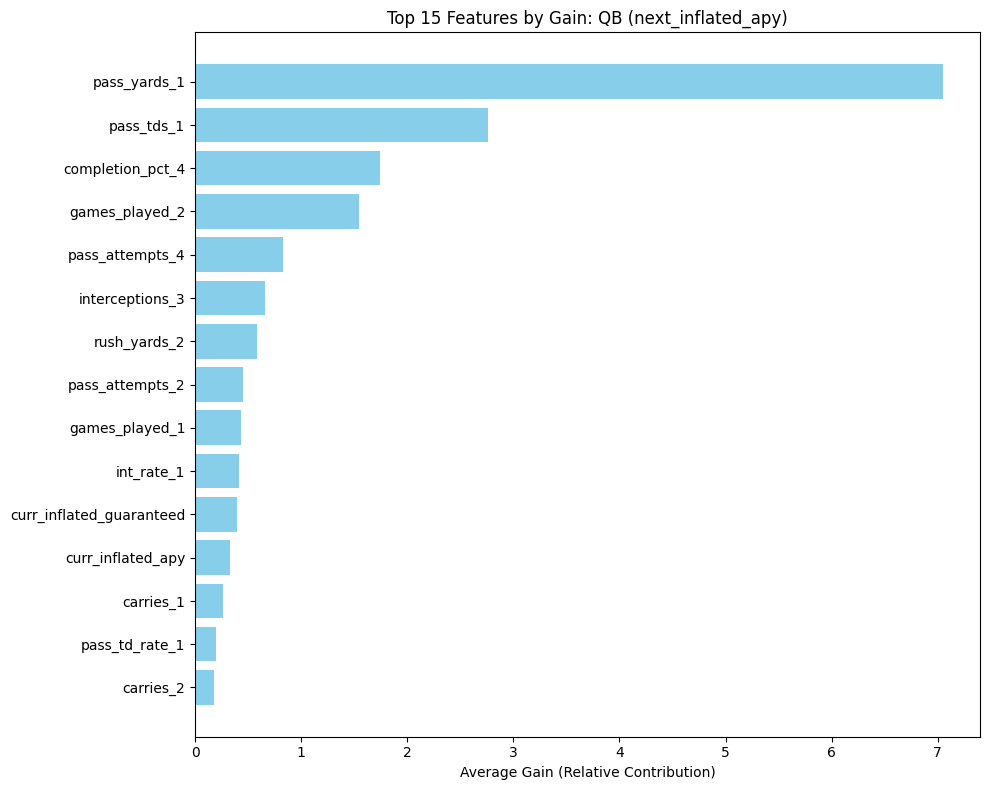

In [0]:
import matplotlib.pyplot as plt

def plot_importance(pos, target='next_inflated_apy'):
    # 1. Access the trained XGBoost model inside the wrapper
    model = final_models[target][pos].regressor_
    
    # 2. Get the gain-based importance dictionary
    # This should already have your names (e.g., 'pass_yards_1') as keys
    importance = model.get_booster().get_score(importance_type='gain')
    
    # 3. Sort and take the top 15
    sorted_importance = dict(sorted(importance.items(), key=lambda item: item[1], reverse=True)[:15])

    # 4. Plot
    plt.figure(figsize=(10, 8))
    plt.barh(list(sorted_importance.keys()), list(sorted_importance.values()), color='skyblue')
    plt.gca().invert_yaxis()
    plt.title(f"Top 15 Features by Gain: {pos} ({target})")
    plt.xlabel("Average Gain (Relative Contribution)")
    plt.tight_layout()
    plt.show()

# Try it now!
plot_importance('QB')

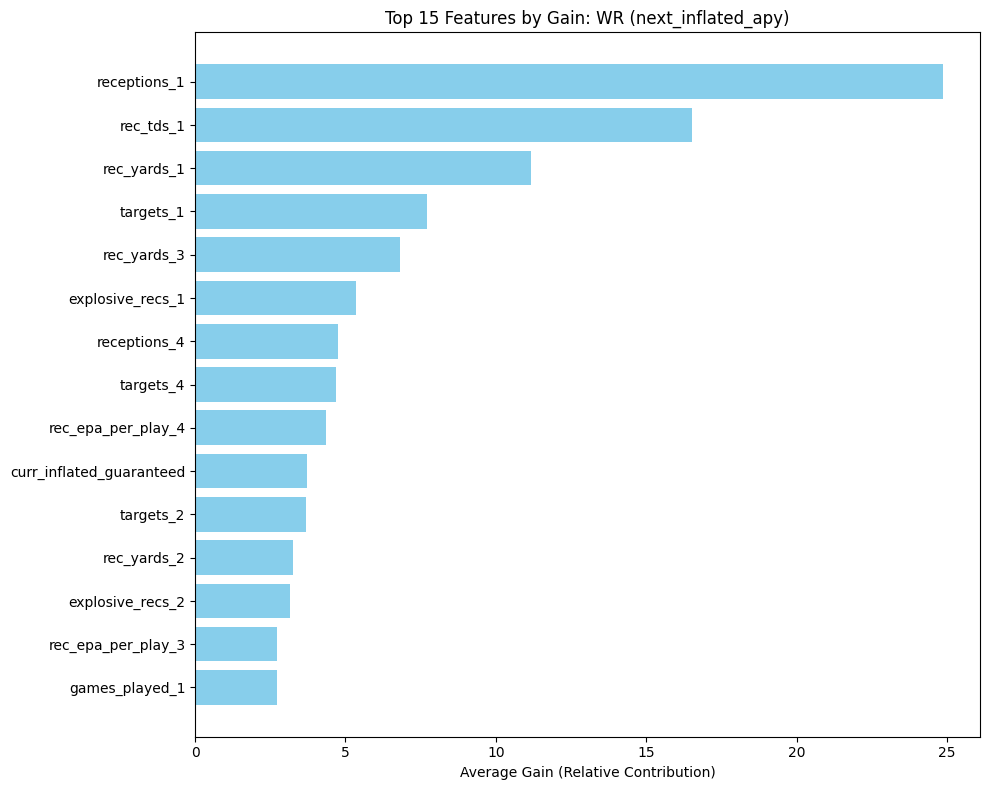

In [0]:
plot_importance('WR')